# 02 — Training Model KNN (3 Fitur: Accel + Gyro + BPM)

Prasyarat: jalankan `01_eksplorasi_data.ipynb` → `data/processed/dataset_clean.csv` harus ada.

In [1]:
import sys, os
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.preprocessing    import MinMaxScaler
from sklearn.metrics          import (accuracy_score, classification_report,
                                      confusion_matrix, ConfusionMatrixDisplay)

from config import (FEATURES, TARGET, CLASSES, CLASS_MAP, BPM_MED_PATH,
                    K_NEIGHBORS, KNN_METRIC, KNN_WEIGHTS, MODEL_PATH, SCALER_PATH)
from utils  import (load_and_clean_dataset, impute_bpm, normalize_features,
                    encode_labels, remove_outliers, get_logger)

logger = get_logger('notebook_02')
sns.set_theme(style='whitegrid')
print('Fitur yang digunakan:', FEATURES)

Fitur yang digunakan: ['accel_stddev', 'gyro_stddev', 'bpm_filled']


## 1. Muat Dataset Bersih

In [2]:
CLEAN_PATH = '../data/processed/dataset_clean.csv'
df_raw = load_and_clean_dataset(CLEAN_PATH)
print(f'Shape: {df_raw.shape}')
print(f'Distribusi kelas:')
print(df_raw[TARGET].value_counts())

Shape: (1541, 7)
Distribusi kelas:
activity
DUDUK       886
BERJALAN    445
BERLARI     210
Name: count, dtype: int64


## 2. Imputasi BPM = 0

BPM = 0 (sensor tidak terbaca) diisi median per kelas dari data training.

In [3]:
df, bpm_medians = impute_bpm(df_raw, fit=True)

# Simpan bpm_medians untuk server_knn.py
joblib.dump(bpm_medians, BPM_MED_PATH)
print('BPM medians disimpan:', BPM_MED_PATH)
print(bpm_medians)

# Hapus outlier
df = remove_outliers(df)
df = encode_labels(df)
print('Dataset setelah preprocessing:', df.shape)

BPM Median per kelas (untuk imputasi):
  DUDUK: 70 bpm
  BERJALAN: 117 bpm
  BERLARI: 151 bpm
  _global: 75 bpm
BPM medians disimpan: c:\Users\LENOVO\Desktop\Documents\folder kuliah\TA\iot\models\bpm_medians.pkl
{'DUDUK': 70, 'BERJALAN': 117, 'BERLARI': 151, '_global': 75}
Dataset setelah preprocessing: (1498, 8)


## 3. Normalisasi 3 Fitur (accel_stddev, gyro_stddev, bpm_filled)

In [4]:
print('Sebelum normalisasi:')
print(df[FEATURES].describe().round(4))

df, scaler = normalize_features(df, fit=True)

print('\nSetelah normalisasi (min=0, max=1):')
print(df[FEATURES].describe().round(4))

Sebelum normalisasi:
       accel_stddev  gyro_stddev  bpm_filled
count     1498.0000    1498.0000   1498.0000
mean         0.0445       7.6057     93.1736
std          0.0764      10.3170     33.6103
min          0.0033       0.0331     32.0000
25%          0.0060       0.5599     69.0000
50%          0.0083       1.5040     74.0000
75%          0.0464      11.1326    117.0000
max          0.3702      45.5192    186.0000

Setelah normalisasi (min=0, max=1):
       accel_stddev  gyro_stddev  bpm_filled
count     1498.0000    1498.0000   1498.0000
mean         0.1123       0.1665      0.3972
std          0.2083       0.2268      0.2182
min          0.0000       0.0000      0.0000
25%          0.0073       0.0116      0.2403
50%          0.0136       0.0323      0.2727
75%          0.1174       0.2440      0.5519
max          1.0000       1.0000      1.0000


## 4. Split Train / Test

In [5]:
X = df[FEATURES].values
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
for cls in CLASSES:
    print(f'  {cls}: train={sum(y_train==cls)} test={sum(y_test==cls)}')

Train: 1198 | Test: 300
  DUDUK: train=709 test=177
  BERJALAN: train=355 test=89
  BERLARI: train=134 test=34


## 5. Hyperparameter Tuning — Cari K Terbaik

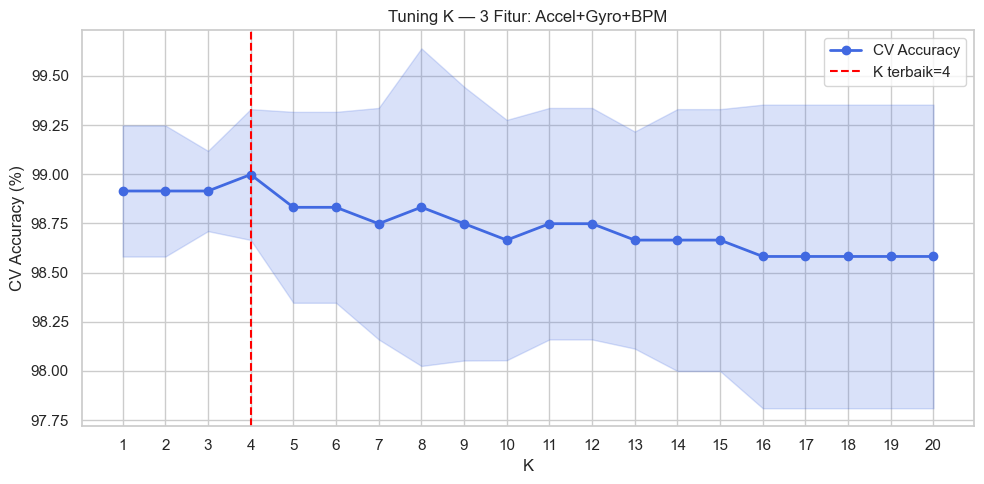

K terbaik: 4 (CV Acc = 99.0 %)


In [6]:
k_range   = range(1, 21)
cv_scores = []; cv_std = []
kfold     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric=KNN_METRIC, weights=KNN_WEIGHTS)
    scores = cross_val_score(knn, X_train, y_train, cv=kfold, scoring='accuracy')
    cv_scores.append(scores.mean()); cv_std.append(scores.std())

cv_scores = np.array(cv_scores); cv_std = np.array(cv_std)
best_k    = list(k_range)[np.argmax(cv_scores)]
best_score= cv_scores.max()

plt.figure(figsize=(10, 5))
plt.plot(list(k_range), cv_scores*100, 'o-', color='royalblue', lw=2, label='CV Accuracy')
plt.fill_between(list(k_range), (cv_scores-cv_std)*100, (cv_scores+cv_std)*100,
                 alpha=0.2, color='royalblue')
plt.axvline(x=best_k, color='red', linestyle='--', label='K terbaik='+str(best_k))
plt.xlabel('K'); plt.ylabel('CV Accuracy (%)'); plt.legend()
plt.title('Tuning K — 3 Fitur: Accel+Gyro+BPM')
plt.xticks(list(k_range)); plt.tight_layout()
plt.savefig('../data/processed/tuning_k_3fitur.png', dpi=150); plt.show()
print('K terbaik:', best_k, '(CV Acc =', round(best_score*100,2), '%)')

## 6. Training Model Final

In [7]:
USE_K = best_k  # bisa override: USE_K = K_NEIGHBORS

knn = KNeighborsClassifier(n_neighbors=USE_K, metric=KNN_METRIC, weights=KNN_WEIGHTS)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
acc    = accuracy_score(y_test, y_pred)
print('K =', USE_K, '| Test Accuracy:', round(acc*100, 2), '%')

K = 4 | Test Accuracy: 97.67 %


## 7. Classification Report

In [8]:
print('=== CLASSIFICATION REPORT — 3 FITUR (Accel+Gyro+BPM) ===')
print(classification_report(y_test, y_pred, target_names=CLASSES, digits=4))

=== CLASSIFICATION REPORT — 3 FITUR (Accel+Gyro+BPM) ===
              precision    recall  f1-score   support

       DUDUK     0.9659    0.9551    0.9605        89
    BERJALAN     0.9688    0.9118    0.9394        34
     BERLARI     0.9833    1.0000    0.9916       177

    accuracy                         0.9767       300
   macro avg     0.9727    0.9556    0.9638       300
weighted avg     0.9765    0.9767    0.9764       300



## 8. Confusion Matrix

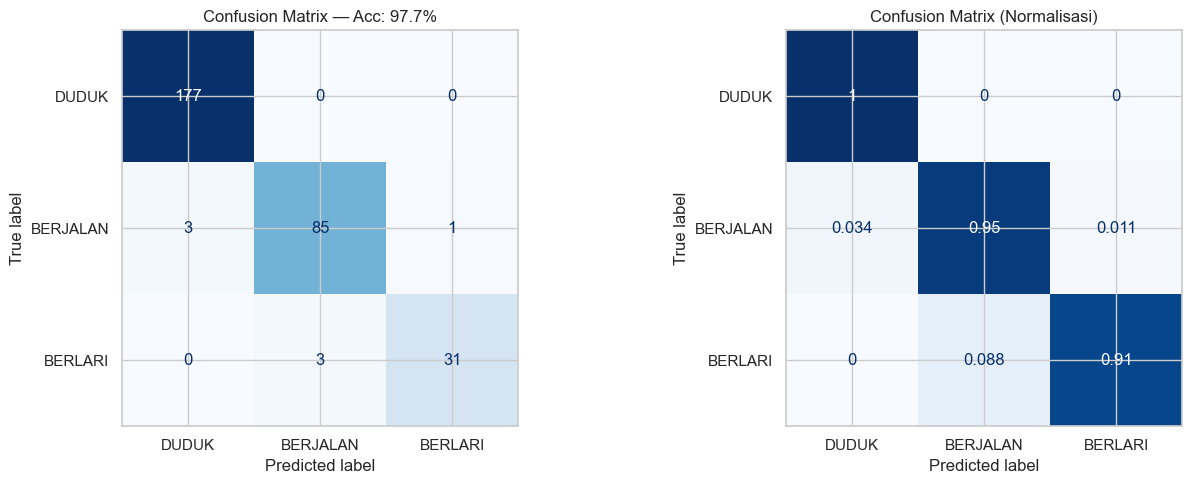

In [9]:
cm = confusion_matrix(y_test, y_pred, labels=CLASSES)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix — Acc: ' + str(round(acc*100,1)) + '%')

cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
ConfusionMatrixDisplay(confusion_matrix=cm_norm.round(3), display_labels=CLASSES).plot(
    ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Confusion Matrix (Normalisasi)')
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix_3fitur.png', dpi=150)
plt.show()

## 9. Kontribusi BPM — Bandingkan 2 vs 3 Fitur

=== PERBANDINGAN KOMBINASI FITUR ===
                   fitur       acc
    Accel+Gyro (2 fitur) 99.333333
Accel+Gyro+BPM (3 fitur) 97.666667
      BPM saja (1 fitur) 83.666667


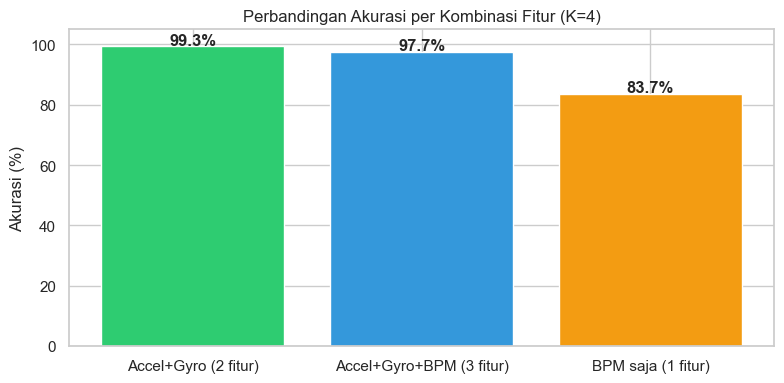


Penambahan BPM meningkatkan akurasi sebesar -1.67 %


In [10]:
results_feat = []

# 3 fitur
results_feat.append({'fitur': 'Accel+Gyro+BPM (3 fitur)', 'acc': acc*100})

# 2 fitur: Accel+Gyro
knn2 = KNeighborsClassifier(n_neighbors=USE_K, metric=KNN_METRIC, weights=KNN_WEIGHTS)
knn2.fit(X_train[:, :2], y_train)
acc2 = accuracy_score(y_test, knn2.predict(X_test[:, :2]))
results_feat.append({'fitur': 'Accel+Gyro (2 fitur)', 'acc': acc2*100})

# BPM saja
knn_b = KNeighborsClassifier(n_neighbors=USE_K, metric=KNN_METRIC, weights=KNN_WEIGHTS)
knn_b.fit(X_train[:, 2:3], y_train)
acc_b = accuracy_score(y_test, knn_b.predict(X_test[:, 2:3]))
results_feat.append({'fitur': 'BPM saja (1 fitur)', 'acc': acc_b*100})

df_res = pd.DataFrame(results_feat).sort_values('acc', ascending=False)
print('=== PERBANDINGAN KOMBINASI FITUR ===')
print(df_res.to_string(index=False))

plt.figure(figsize=(8, 4))
bars = plt.bar(df_res['fitur'], df_res['acc'],
               color=['#2ecc71', '#3498db', '#f39c12'])
plt.ylabel('Akurasi (%)')
plt.title('Perbandingan Akurasi per Kombinasi Fitur (K=' + str(USE_K) + ')')
plt.ylim(0, 105)
for bar, val in zip(bars, df_res['acc']):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             str(round(val,1))+'%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/feature_importance.png', dpi=150)
plt.show()

gain = acc*100 - acc2*100
print('\nPenambahan BPM meningkatkan akurasi sebesar', round(gain,2), '%')

## 10. Simpan Model, Scaler, BPM Medians

In [11]:
joblib.dump(knn,         MODEL_PATH)
joblib.dump(scaler,      SCALER_PATH)
joblib.dump(bpm_medians, BPM_MED_PATH)

print('Model  ->', MODEL_PATH)
print('Scaler ->', SCALER_PATH)
print('BPM    ->', BPM_MED_PATH)
print()
print('=== RINGKASAN MODEL ===')
print('Algoritma :', 'KNN')
print('K         :', USE_K)
print('Fitur     :', FEATURES)
print('BPM med   :', bpm_medians)
print('Test Acc  :', round(acc*100, 2), '%')

Model  -> c:\Users\LENOVO\Desktop\Documents\folder kuliah\TA\iot\models\knn_model.pkl
Scaler -> c:\Users\LENOVO\Desktop\Documents\folder kuliah\TA\iot\models\scaler.pkl
BPM    -> c:\Users\LENOVO\Desktop\Documents\folder kuliah\TA\iot\models\bpm_medians.pkl

=== RINGKASAN MODEL ===
Algoritma : KNN
K         : 4
Fitur     : ['accel_stddev', 'gyro_stddev', 'bpm_filled']
BPM med   : {'DUDUK': 70, 'BERJALAN': 117, 'BERLARI': 151, '_global': 75}
Test Acc  : 97.67 %


## 11. Perbandingan Metric Jarak (Opsional)

In [12]:
results = []
for metric in ['euclidean', 'manhattan', 'chebyshev']:
    for w in ['uniform', 'distance']:
        knn_tmp = KNeighborsClassifier(n_neighbors=USE_K, metric=metric, weights=w)
        scores  = cross_val_score(knn_tmp, X_train, y_train, cv=kfold, scoring='accuracy')
        results.append({'metric':metric,'weights':w,
                         'cv_mean':round(scores.mean()*100,2),
                         'cv_std':round(scores.std()*100,2)})
df_m = pd.DataFrame(results).sort_values('cv_mean', ascending=False)
print('=== Perbandingan Konfigurasi KNN ===')
print(df_m.to_string(index=False))

=== Perbandingan Konfigurasi KNN ===
   metric  weights  cv_mean  cv_std
manhattan distance    99.17    0.26
euclidean distance    99.00    0.33
chebyshev distance    98.92    0.33
manhattan  uniform    98.58    0.77
euclidean  uniform    98.50    0.77
chebyshev  uniform    98.25    0.85
